In [ ]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [ ]:
nc_in = r'O:\HybridDune experiment\data Kellers\NetCDF\pressure transducers file 1, 16-18dec2024 (before storm1), 10Hz.nc'
ds = xr.open_dataset(nc_in)

with xr.open_dataset(nc_in) as ds: # open with context manager so the file is closed immediately
    # Define variables 
    U = ds['voltage']
    z_i = ds['z_instrument']
    t = ds['t']

p = 1e5 * (0.15*U+0.5) # Convert voltage to pressure in Pa
p_ref = p[4, 0, :].rolling(t=10*10).mean() # window 10s * 10 hz. NB: Python indexing starts at 0, so sensor ref.Pt1, stored under 'section 5' is here index 4. Sensor 1 is index 0. 
p = p - p_ref # subtract air pressure
p = p / 10000 * 100 # Convert Pa to m to cm, for plotting. NB: rough conversion, for accuracy use g, rho

# NB: For the large files with 1000 hz, load in chunks (parts) to prevent memory overload. This requires/automatically calls dask. 
# Consider loading only a subset of the full timeseries. Replace the file loading line with e.g.:
# with xr.open_dataset(nc_in, chunks="auto").isel(t=slice(0, None, 100)) as ds:  # downsample: every 100th timestep, so 10 Hz instead of 1000 Hz

In [4]:
ds # Print dims, vars, etc of dataset

<xarray.Dataset> Size: 872MB
Dimensions:       (section: 5, sensor: 12, t: 1786324)
Coordinates:
  * section       (section) <U15 300B 'S1 Dike-in-dune' '' ... 'ref.Pt1'
  * t             (t) datetime64[ns] 14MB 2024-12-16T14:56:54 ... 2024-12-18T...
    temp          int64 8B ...
Dimensions without coordinates: sensor
Data variables:
    voltage       (section, sensor, t) float64 857MB 3.534 3.534 ... nan nan
    x_RD          (section, sensor) float64 480B ...
    y_RD          (section, sensor) float64 480B ...
    x_local       (section, sensor) float64 480B ...
    y_local       (section, sensor) float64 480B ...
    z_instrument  (section, sensor) float64 480B ...
    sf            int64 8B ...
Attributes:
    name:                   O:\HybridDune experiment\data Kellers\2024-12-16 ...
    period:                 storm 3, 2024-12-16 14:56 to 2024-12-18 16:34
    instrument type:        Keller PAA-36XW
    time zone:              UTC+1
    summary:                Hybrid Dune campaign, data of Keller pressure sen...
    contact person:         Daan Poppema
    emailadres:             d.w.poppema@tudelft.nl
    modification datetime:  27-Oct-2025 16:34:25
    version:                v1
    epsg:                   28992
    recording date:         2024-12-16 14:56:54
    time step:              0.1 sec.

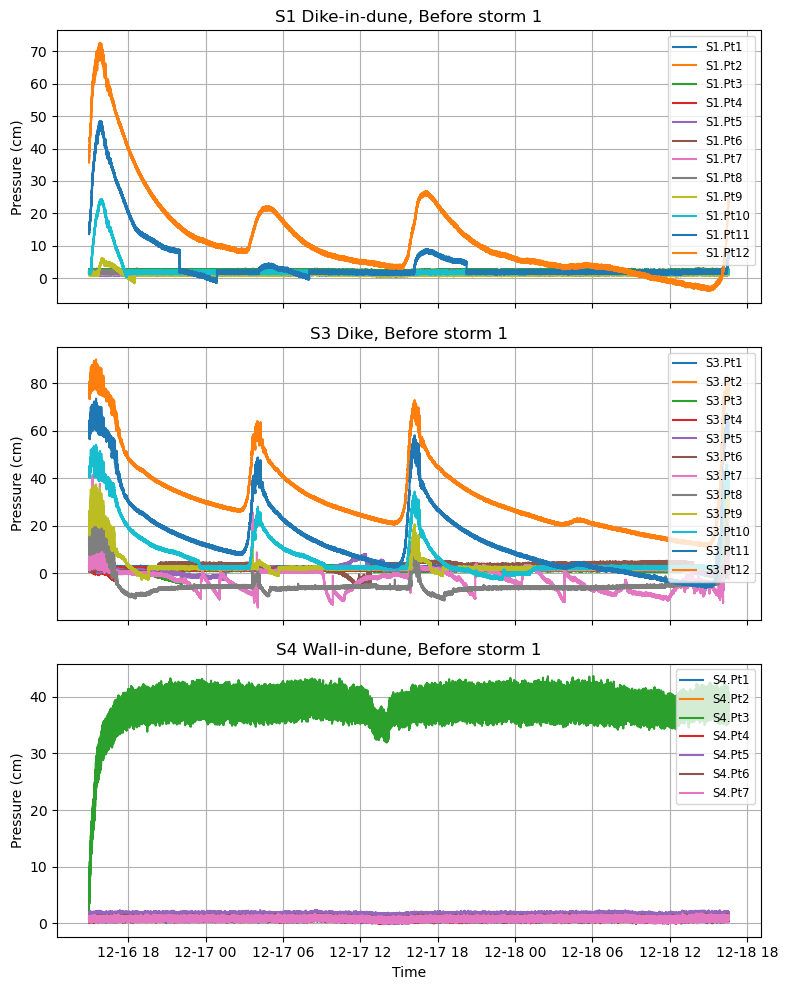

In [5]:
# Make plot -------------------------------------------------------------------
sections = [1, 3, 4]   # S1, S3 and S4
n_sensors = {1: 12, 3: 12, 4: 7}  # number of sensors in S1, S3 and S4
titles = ['S1 Dike-in-dune', 'S3 Dike', 'S4 Wall-in-dune']

fig, axes = plt.subplots(3, 1, figsize=(8, 10), sharex=True)

for ax, s, title in zip(axes, sections, titles):
    # Plot all sensors as separate lines
    for n in range(n_sensors[s]):  # iterate over sensors for this section. 
        ax.plot(t[::5], p[s-1, n, ::5], label=f'S{s}.Pt{n+1}')  # s-1 because sections are 1-indexed, but python is 0-indexed.    ::5 to plot every 5th point (2 Hz) and plot fewer points
    ax.set_ylabel('Pressure (cm)')
    ax.set_title(f'{title}, Before storm 1')
    ax.grid(True)
    ax.legend(loc='upper right', fontsize='small')

axes[-1].set_xlabel('Time')
plt.tight_layout()
plt.show()